In [1]:
from astropy.io import fits as ft
data_loc = "/home/rohan/agn_photometry/data/dr16q_prop_May01_2024.fits"

In [2]:
with ft.open(data_loc) as hdul:
    print(hdul.info())

Filename: /home/rohan/agn_photometry/data/dr16q_prop_May01_2024.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    238   750414R x 115C   [18A, K, K, K, D, D, 20A, 10A, D, 12A, D, D, D, D, D, 5D, 5D, 2D, 3D, 3D, D, D, 3D, 3D, D, D, D, D, D, D, D, D, D, D, D, D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 6D, 2D, 2D, 2D, 2D, 2D, 2D, 2D, 2D, 2D, 2D, D, D, D, D, D, D, D, D, D, D, D, D, 8D, 8D, D]   
  2                1 BinTableHDU    188   750414R x 90C   [5D, 5D, 5D, E, D, D, D, D, D, D, D, D, J, J, J, 5E, 5D, 5E, 5D, 5E, D, D, I, D, D, D, D, I, D, D, D, D, D, D, D, D, E, E, E, E, E, E, E, E, E, I, E, E, E, E, E, E, E, E, E, I, I, D, D, D, D, D, D, J, D, D, D, J, D, D, D, J, D, 21A, D, D, E, E, D, K, D, D, E, E, E, E, E,

In [3]:
data_loc = "/home/rohan/agn_photometry/data/dr16q_prop_May01_2024.fits"
with ft.open(data_loc, memmap=True) as hdul:
    data = hdul[1].data
    xdata = data['FEII_OPT'].copy()  
    

In [4]:
import fitsio
import polars as pl
import matplotlib.pyplot as plt
data_loc = "/home/rohan/agn_photometry/data/dr16q_prop_May01_2024.fits"
from astropy.table import Table
#table = Table.read(data_loc, hdu=1, memmap=True)
#print(table.colnames)
columns = ['FEII_OPT_EW', 'FEII_OPT_EW_ERR', 'HBETA_BR', 'HBETA_BR_ERR', 'Z_FIT']
raw_data = fitsio.read(data_loc, ext=1, columns=columns)
df = pl.DataFrame({col: raw_data[col].tolist() for col in raw_data.dtype.names}).lazy()


In [5]:
processed_df = (
    df
    .with_columns([
        pl.col("HBETA_BR").list.get(5).alias("HB_EW"),
        pl.col("HBETA_BR").list.get(4).alias("HB_FWHM"),
        pl.col("HBETA_BR_ERR").list.get(5).alias("HB_EW_ERR"),
    ])
    .with_columns([
        (pl.col("FEII_OPT_EW") / pl.col("HB_EW")).alias("R_Fe"),
        (((pl.col("FEII_OPT_EW_ERR") / pl.col("FEII_OPT_EW"))**2 + 
          (pl.col("HB_EW_ERR") / pl.col("HB_EW"))**2).sqrt()
        ).fill_nan(1.0).alias("rel_err_rfe")
    ])
    .filter(
        (pl.col("R_Fe") != 0) & 
        (pl.col("HB_FWHM") != 0) & 
        (pl.col("rel_err_rfe") < 0.20)
    )
    .collect()
)

In [6]:
display_table = Table.from_pandas(processed_df.head(10).to_pandas())
print("Top 10 High-Quality Sources:")
print(display_table)

Top 10 High-Quality Sources:
      Z_FIT           FEII_OPT_EW     ...     rel_err_rfe     
------------------ ------------------ ... --------------------
0.8454347848892212  65.84736750657055 ...  0.12098504655566522
0.2863158583641052  72.99615247792316 ...  0.10492754974209693
0.3142540752887726  33.87229034550267 ...   0.1698633984698297
          0.460127  53.25781566751532 ...  0.11268946312663482
0.4795550405979156  96.83466364774692 ...   0.1301944330952006
0.3892785012722015  34.01361594010611 ...  0.10991081816680201
0.4138045310974121 45.083364011992686 ... 0.046582945352308926
 0.639323890209198 50.393215372107726 ...  0.14638468524479073
 0.537075400352478   26.8557378530009 ...  0.07565917212035109
0.4163996279239654  49.90281764240861 ...  0.11448939767168374


In [7]:
#print(df['HBETA_BR'][:,4]) #fhwm?
print(df.select(pl.col("HBETA_BR").list.get(4)).collect().head())

shape: (5, 1)
┌─────────────┐
│ HBETA_BR    │
│ ---         │
│ f64         │
╞═════════════╡
│ 5690.050363 │
│ 0.0         │
│ 0.0         │
│ 0.0         │
│ 0.0         │
└─────────────┘


In [8]:
#print(table['HBETA_BR'][:,5]) #ew?
#print(table['HBETA_BR'][:,5]) #ew?
print(df.select(pl.col("HBETA_BR").list.get(5)).collect().head())

shape: (5, 1)
┌────────────┐
│ HBETA_BR   │
│ ---        │
│ f64        │
╞════════════╡
│ 158.550242 │
│ 0.0        │
│ 0.0        │
│ 0.0        │
│ 0.0        │
└────────────┘


In [9]:
#print(table['FEII_OPT_EW'])
#print(table['HBETA_BR'][:,5]) #ew?
print(df.select(pl.col("FEII_OPT_EW")).collect().head())


shape: (5, 1)
┌─────────────┐
│ FEII_OPT_EW │
│ ---         │
│ f64         │
╞═════════════╡
│ 65.847368   │
│ 0.0         │
│ 0.0         │
│ 0.0         │
│ 0.0         │
└─────────────┘


In [10]:
#import numpy as np
#rfe =np.log(np.divide(table['FEII_OPT_EW'], table['HBETA_BR'][:,5], out = np.zeros_like(table['FEII_OPT_EW']), where=table['HBETA_BR'][:,5]!=0))
#print(rfe)

In [11]:
r_fe = processed_df["R_Fe"].to_numpy()
fwhm_ = processed_df["HB_FWHM"].to_numpy()

In [12]:
r_fe

array([0.41530916, 1.3028543 , 1.01685282, ..., 0.83610626, 0.83827361,
       1.20146164], shape=(26682,))

In [17]:
import fitsio
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
data_loc = "/home/rohan/agn_photometry/data/dr16q_prop_May01_2024.fits"
columns = [
    'FEII_OPT_EW', 'FEII_OPT_EW_ERR', 'HBETA_BR', 'HBETA_BR_ERR', 
    'Z_FIT', 'LOGL5100', 'RA', 'DEC', 'SDSS_NAME', 'PLATE', 'MJD', 'FIBERID', 'OBJID'
]
raw_data = fitsio.read(data_loc, ext=1, columns=columns)
df = pl.DataFrame({col: raw_data[col].tolist() for col in raw_data.dtype.names}).lazy()
##data = Table.read(data_loc, hdu=1, memmap=True)
#fwhm_hbeta = data['HBETA_BR'][:,4].copy()
#fe_ew = data['FEII_OPT_EW'].copy()
#hb_ew = data['HBETA_BR'][:,5].copy()
#fe_err = data['FEII_OPT_EW_ERR'].copy()
#hb_err = data['HBETA_BR_ERR'][:, 5].copy()
#R_Fe =np.divide(fe_ew, hb_ew, out = np.zeros_like(fe_ew), where=hb_ew!=0)
#with np.errstate(divide='ignore', invalid='ignore'):
    #rel_err_rfe = np.sqrt((fe_err / fe_ew)**2 + (hb_err / hb_ew)**2)
    #rel_err_rfe = np.nan_to_num(rel_err_rfe, nan=1.0)

In [18]:
processed_df = (
    df.with_columns([
        pl.col("HBETA_BR").list.get(5).alias("hb_ew"),
        pl.col("HBETA_BR").list.get(4).alias("fwhm_hbeta"),
        pl.col("HBETA_BR_ERR").list.get(5).alias("hb_ew_err"),
        pl.col("HBETA_BR_ERR").list.get(4).alias("fwhm_hbeta_err"),
    ])
    .with_columns([
        (pl.col("FEII_OPT_EW") / pl.col("hb_ew")).alias("R_Fe"),
        (((pl.col("FEII_OPT_EW_ERR") / pl.col("FEII_OPT_EW")).pow(2) + 
          (pl.col("hb_ew_err") / pl.col("hb_ew")).pow(2)).sqrt()
        ).fill_nan(1.0).alias("rel_err_rfe"),
        (pl.col("fwhm_hbeta_err") / pl.col("fwhm_hbeta")).fill_nan(1.0).alias("rel_err_fwhm"),
    ])
    .filter(
        (pl.col("R_Fe") != 0) & 
        (pl.col("fwhm_hbeta") != 0) & 
        (pl.col("rel_err_rfe") < 0.20) &
        (pl.col("rel_err_fwhm") < 0.20) &
        (pl.col("Z_FIT") > 0.05) &
        (pl.col("Z_FIT") < 0.6) &
        (pl.col("hb_ew") > 10) &          # broad Hβ EW > 10Å — stars won't have this
        (pl.col("FEII_OPT_EW") > 5) &     # real optical FeII emission
        (pl.col("fwhm_hbeta") > 1000)     # FWHM > 1000 km/s — stellar absorption is narrow
    )
    .collect()
)

In [19]:
R_Fe_filtered = processed_df["R_Fe"].to_numpy()
fwhm_filtered = processed_df["fwhm_hbeta"].to_numpy()
z_fit_filtered = processed_df["Z_FIT"].to_numpy()
logl5100_filtered = processed_df["LOGL5100"].to_numpy()

In [20]:
print(f"Total High-Quality Sources Isolated: {len(R_Fe_filtered)}")

Total High-Quality Sources Isolated: 12224


In [21]:
import requests

def get_classes_batch(rows):
    url = "https://skyserver.sdss.org/dr18/SkyServerWS/SearchTools/SqlSearch"
    conditions = " OR ".join(
        f"(s.plate={r['PLATE']} AND s.mjd={r['MJD']} AND s.fiberid={r['FIBERID']})"
        for r in rows
    )
    query = f"""SELECT s.plate, s.mjd, s.fiberid, s.class, s.subClass, s.zWarning, p.type
FROM SpecObj s JOIN PhotoObj p ON s.bestobjid = p.objid
WHERE {conditions}"""
    try:
        r = requests.get(url, params={"cmd": query, "format": "json"}, timeout=30)
        r.raise_for_status()
        res = r.json()
        result_map = {}
        if res and isinstance(res, list):
            for row in res[0].get("Rows", []):
                key = (row["plate"], row["mjd"], row["fiberid"])
                result_map[key] = {
                    "class": str(row.get("class", "")).strip().upper(),
                    "subClass": str(row.get("subClass", "")).strip().upper(),
                    "zWarning": int(row.get("zWarning", 1)),
                    "type": int(row.get("type", 6))
                }
        return result_map
    except Exception as e:
        print(f"[WARNING] Batch API call failed: {e}")
        return {}

def get_confirmed_agns(candidates_df, quota=20, batch_size=50):
    confirmed = []
    all_rows = list(candidates_df.iter_rows(named=True))
    for i in range(0, len(all_rows), batch_size):
        if len(confirmed) >= quota:
            break
        batch = all_rows[i:i+batch_size]
        class_map = get_classes_batch(batch)
        for row in batch:
            if len(confirmed) >= quota:
                break
            key = (row["PLATE"], row["MJD"], row["FIBERID"])
            result = class_map.get(key)
            if result is None:
                print(f"  Unverified (not in SpecObj): {key}")
                continue
            obj_class = result["class"]
            subclass = result["subClass"]
            z_warn = result["zWarning"]
            phot_type = result["type"]  # 6=STAR, 3=GALAXY in PhotoObj
            if z_warn != 0:
                print(f"  Rejected zWarning={z_warn}: {key}")
                continue
            if obj_class == "STAR" or phot_type == 6:
                print(f"  Rejected STAR (spec={obj_class}, photo={phot_type}): {key}")
                continue
            if obj_class == "QSO":
                confirmed.append(row)
            elif obj_class == "GALAXY" and ("AGN" in subclass or "BROADLINE" in subclass):
                confirmed.append(row)
            else:
                print(f"  Rejected ({obj_class} / {subclass}): {key}")
    return pl.DataFrame(confirmed)

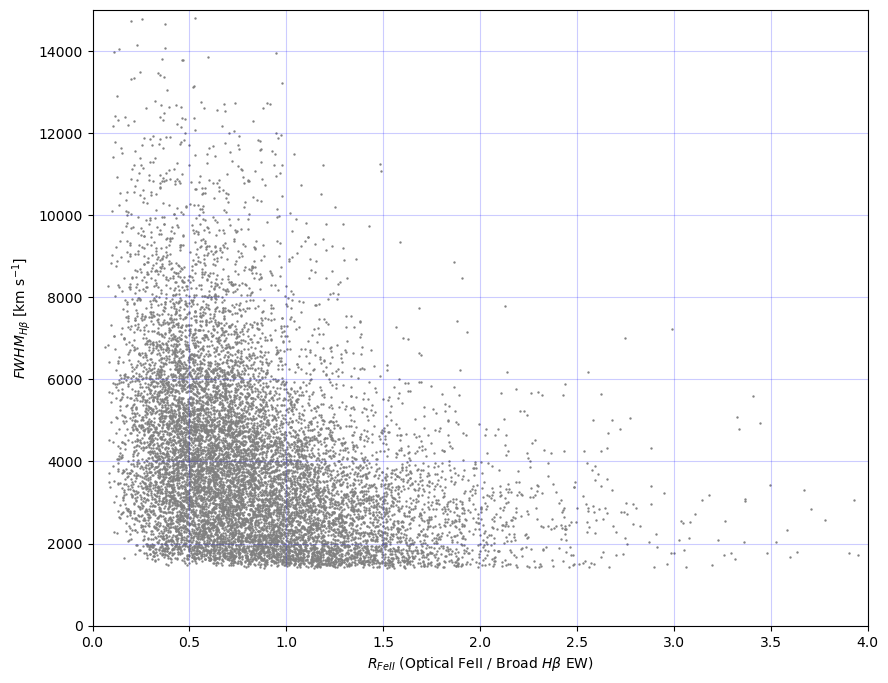

In [22]:
plt.figure(figsize=(10, 8))
plt.scatter(R_Fe_filtered, fwhm_filtered, color = 'gray', alpha=1, s=.5, rasterized = True)
plt.xlabel(r'$R_{FeII}$ (Optical FeII / Broad $H\beta$ EW)')
plt.ylabel(r'$FWHM_{H\beta}$ [km s$^{-1}$]')
plt.xlim(0, 4)
plt.ylim(0, 15000)
plt.grid(True, color='blue', alpha=0.2)
plt.show()

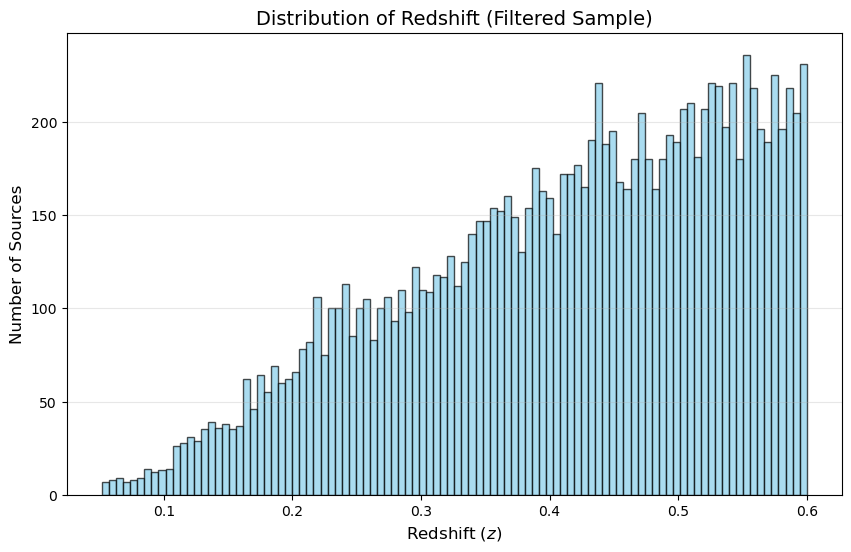

In [23]:
plt.figure(figsize=(10, 6))
#plt.hist(data['Z_FIT'][mask], bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.hist(z_fit_filtered, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Redshift (Filtered Sample)', fontsize=14)
plt.xlabel('Redshift ($z$)', fontsize=12)
plt.ylabel('Number of Sources', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

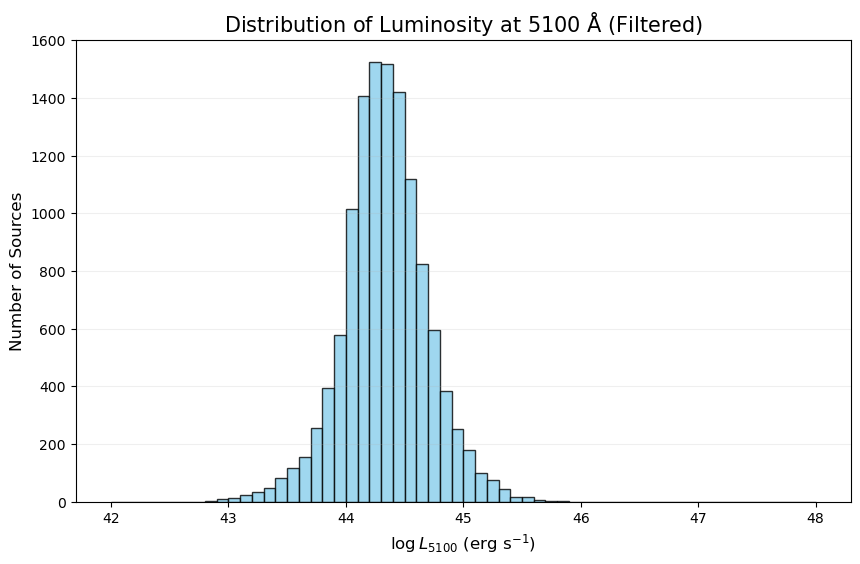

In [24]:
plt.figure(figsize=(10, 6))
#plt.hist(data['LOGL5100'][mask], bins=60, range=(42, 48), color='skyblue', edgecolor='black', alpha=0.8)
plt.hist(logl5100_filtered, bins=60, range=(42, 48), color='skyblue', edgecolor='black', alpha=0.8)
plt.title(r'Distribution of Luminosity at 5100 $\mathrm{\AA}$ (Filtered)', fontsize=15)
plt.xlabel(r'$\log L_{5100}$ ($\mathrm{erg\ s^{-1}}$)', fontsize=12)
plt.ylabel('Number of Sources', fontsize=12)
plt.grid(axis='y', linestyle='-', alpha=0.2)
plt.show()

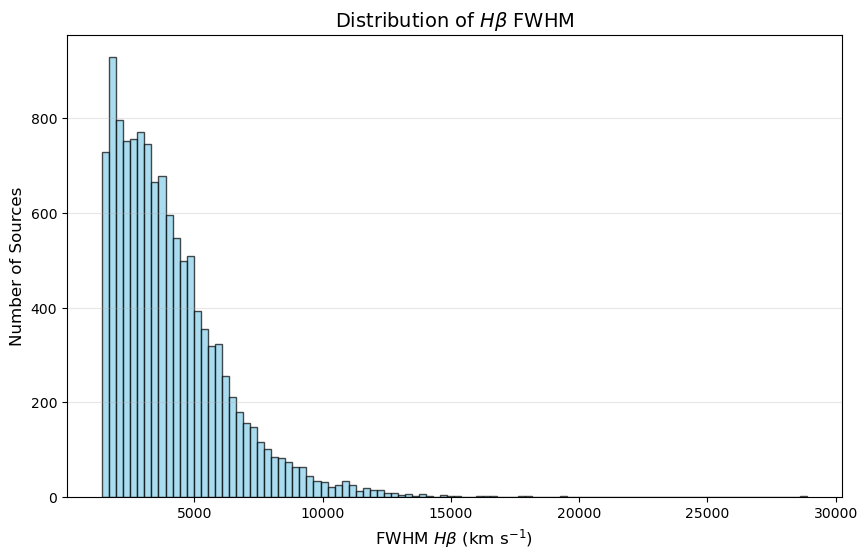

In [25]:
plt.figure(figsize=(10, 6))
#plt.hist(fwhm_hbeta[mask], bins=100
#         , color='skyblue', edgecolor='black', alpha=0.7)
plt.hist(fwhm_filtered, bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of $H\\beta$ FWHM', fontsize=14)
plt.xlabel('FWHM $H\\beta$ (km s$^{-1}$)', fontsize=12)
plt.ylabel('Number of Sources', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

/tmp/ipykernel_19971/1848721712.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


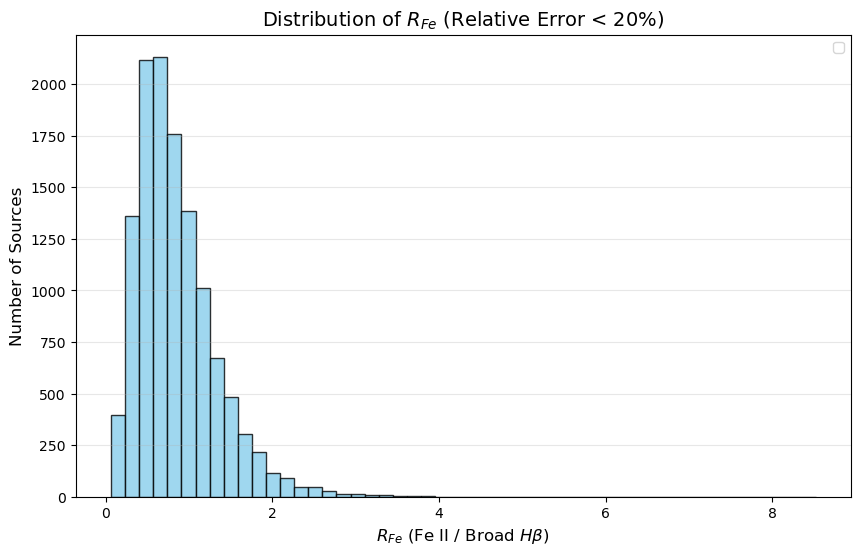

In [26]:
plt.figure(figsize=(10, 6))
#plt.hist(R_Fe[mask], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.hist(R_Fe_filtered, bins=50, color='skyblue', edgecolor='black', alpha=0.8)
plt.title('Distribution of $R_{Fe}$ (Relative Error < 20%)', fontsize=14)
plt.xlabel('$R_{Fe}$ (Fe II / Broad $H\\beta$)', fontsize=12)
plt.ylabel('Number of Sources', fontsize=12)
#plt.xlim(0, 4) 
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

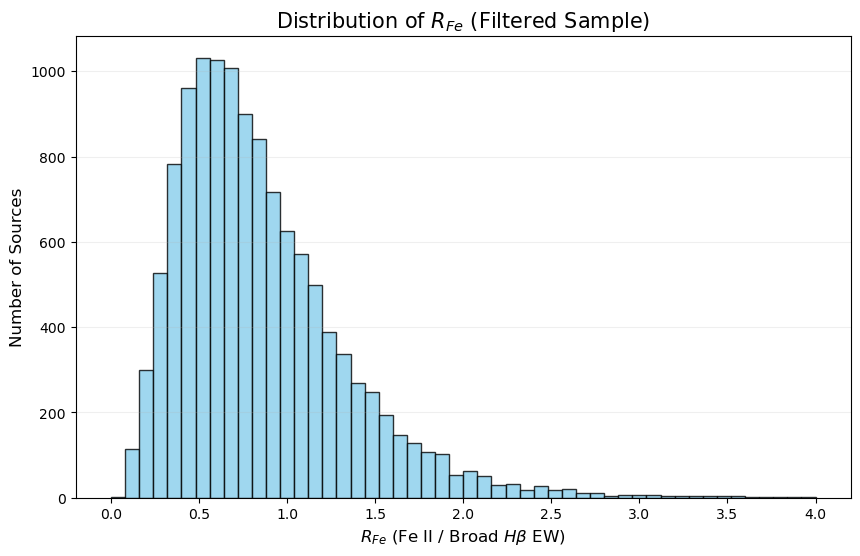

Total High-Quality Sources: 12224


In [27]:
plt.figure(figsize=(10, 6))
#plt.hist(R_Fe[mask], bins=50, range=(0, 4), color='skyblue', edgecolor='black', alpha=0.8)
plt.hist(R_Fe_filtered, bins=50, range=(0, 4), color='skyblue', edgecolor='black', alpha=0.8)
plt.title(r'Distribution of $R_{Fe}$ (Filtered Sample)', fontsize=15)
plt.xlabel(r'$R_{Fe}$ (Fe II / Broad $H\beta$ EW)', fontsize=12)
plt.ylabel('Number of Sources', fontsize=12)
plt.grid(axis='y', linestyle='-', alpha=0.2)
plt.show()
#print(f"Total High-Quality Sources: {np.sum(mask)}")
print(f"Total High-Quality Sources: {len(R_Fe_filtered)}")

In [28]:
TARGET_QUOTA = 20

top_10_rfe = get_confirmed_agns(
    processed_df.filter(pl.col("R_Fe") > 3).sort("LOGL5100", descending=True),
    quota=TARGET_QUOTA
)
print(f"High R_Fe confirmed AGNs: {len(top_10_rfe)}")

top_10_fwhm = get_confirmed_agns(
    processed_df.filter(pl.col("fwhm_hbeta") > 12000).sort("LOGL5100", descending=True),
    quota=TARGET_QUOTA
)
print(f"High FWHM confirmed AGNs: {len(top_10_fwhm)}")

  Unverified (not in SpecObj): (11379, 58438, 592)
  Rejected STAR (spec=QSO, photo=6): (9363, 57742, 730)
  Rejected STAR (spec=QSO, photo=6): (8210, 57426, 734)
  Rejected STAR (spec=QSO, photo=6): (1690, 53475, 4)
  Rejected STAR (spec=QSO, photo=6): (1797, 54507, 220)
  Rejected STAR (spec=QSO, photo=6): (7600, 56984, 472)
  Rejected STAR (spec=QSO, photo=6): (3836, 55302, 726)
  Rejected STAR (spec=QSO, photo=6): (7871, 56902, 74)
  Unverified (not in SpecObj): (623, 52051, 509)
  Rejected STAR (spec=QSO, photo=6): (939, 52636, 456)
  Rejected STAR (spec=QSO, photo=6): (1467, 53115, 471)
  Rejected STAR (spec=QSO, photo=6): (11044, 58508, 838)
  Rejected STAR (spec=QSO, photo=6): (7595, 56957, 190)
  Rejected STAR (spec=QSO, photo=6): (8853, 57459, 232)
  Rejected STAR (spec=QSO, photo=6): (9561, 57809, 230)
  Rejected STAR (spec=QSO, photo=6): (726, 52226, 613)
  Rejected STAR (spec=QSO, photo=6): (10915, 58257, 428)
  Rejected STAR (spec=QSO, photo=6): (10901, 58397, 175)
  Reje

In [29]:
combined_targets = pl.concat([top_10_rfe, top_10_fwhm]).unique()
print(f"Total Unique Extremity Targets Combined: {len(combined_targets)}")

Total Unique Extremity Targets Combined: 32


In [30]:
combined_targets = combined_targets.with_columns([
    (pl.lit("https://skyserver.sdss.org/dr18/VisualTools/explore/summary?plate=") +
     pl.col("PLATE").cast(pl.Utf8) + pl.lit("&mjd=") + pl.col("MJD").cast(pl.Utf8) +
     pl.lit("&fiber=") + pl.col("FIBERID").cast(pl.Utf8)).alias("Link")
])

In [31]:
combined_targets.head

<bound method DataFrame.head of shape: (32, 21)
┌──────────────┬───────┬───────┬─────────┬───┬──────────┬─────────────┬──────────────┬─────────────┐
│ SDSS_NAME    ┆ PLATE ┆ MJD   ┆ FIBERID ┆ … ┆ R_Fe     ┆ rel_err_rfe ┆ rel_err_fwhm ┆ Link        │
│ ---          ┆ ---   ┆ ---   ┆ ---     ┆   ┆ ---      ┆ ---         ┆ ---          ┆ ---         │
│ str          ┆ i64   ┆ i64   ┆ i64     ┆   ┆ f64      ┆ f64         ┆ f64          ┆ str         │
╞══════════════╪═══════╪═══════╪═════════╪═══╪══════════╪═════════════╪══════════════╪═════════════╡
│ 220546.32+00 ┆ 4199  ┆ 55481 ┆ 750     ┆ … ┆ 3.902005 ┆ 0.044524    ┆ 0.084721     ┆ https://sky │
│ 5319.2       ┆       ┆       ┆         ┆   ┆          ┆             ┆              ┆ server.sdss │
│              ┆       ┆       ┆         ┆   ┆          ┆             ┆              ┆ .org/dr1…   │
│ 172052.29+59 ┆ 366   ┆ 52017 ┆ 354     ┆ … ┆ 0.914765 ┆ 0.173758    ┆ 0.089518     ┆ https://sky │
│ 0153.7       ┆       ┆       ┆         ┆ 

In [32]:
final_target_table = combined_targets.select([
    pl.col("SDSS_NAME").cast(pl.Utf8).alias("Name of the source"),
    pl.col("RA"),
    pl.col("DEC"),
    pl.col("Z_FIT").alias("redshift"),
    pl.col("FIBERID").alias("FIBER"),
    pl.col("MJD"),
    pl.col("PLATE"),
    pl.col("Link")
])

In [33]:
output_path = "/home/rohan/agn_photometry/sdss_data_plot_reproduction/results/sdss_meeting_targets_dr18.csv"
final_target_table.write_csv(output_path)
print(f"Target table successfully generated with {final_target_table.height} unique sources.")

Target table successfully generated with 32 unique sources.


In [34]:
from astropy.table import Table
display_targets = Table({col: final_target_table[col].to_numpy() for col in final_target_table.columns})

display_targets.pprint_all()

Name of the source         RA                 DEC              redshift      FIBER  MJD  PLATE                                             Link                                           
------------------ ------------------ ------------------- ------------------ ----- ----- ----- -------------------------------------------------------------------------------------------
220546.32+005319.2  331.4430402844544  0.8886892407921507              0.285   750 55481  4199  https://skyserver.sdss.org/dr18/VisualTools/explore/summary?plate=4199&mjd=55481&fiber=750
172052.29+590153.7         260.217914           59.031587           0.351248   354 52017   366   https://skyserver.sdss.org/dr18/VisualTools/explore/summary?plate=366&mjd=52017&fiber=354
001255.59+014750.9  3.231666122073648   1.797483230308588 0.4335806667804718   238 56988  7853  https://skyserver.sdss.org/dr18/VisualTools/explore/summary?plate=7853&mjd=56988&fiber=238
134406.11+392817.4         206.025492           39.471524        